# Does the data fit a **Gamma** or a **Gaussian** distribution?

In [1]:
import numpy as np
import torch
from torchvision import datasets
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(0)

## 1. settings

In [2]:
SEL      = [0, 2, 3]                  # Fashion-MNIST: 0=T-shirt/top, 2=Pullover, 3=Dress
NAMES    = ['T-shirt', 'Pullover', 'Dress']
n_images = 1500                       # images per class to analyze
fg_thresh = 0.05                      # foreground threshold (ignore near-black background pixels)
max_pixels = 150_000                  # subsample this many pixel values per analysis (speed)
bins = 100

## 2. load data

In [3]:
fm = datasets.FashionMNIST(root='../data', train=True, download=True)

pix_by_class = {}
for c, orig in enumerate(SEL):
    idx = (fm.targets == orig).nonzero(as_tuple=False).squeeze(1)[:n_images]
    imgs = (fm.data[idx].float() / 255.0).numpy()      # [n, 28, 28] in [0, 1]
    pix_by_class[c] = imgs

all_imgs = np.concatenate([pix_by_class[c] for c in range(len(SEL))], axis=0)
print(f"loaded {all_imgs.shape[0]} images ({all_imgs.shape[1]}x{all_imgs.shape[2]})")

def foreground_pixels(imgs):
    """Flatten to 1-D, keep foreground pixels (> fg_thresh), subsample for speed."""
    v = imgs.ravel()
    v = v[v > fg_thresh]
    if len(v) > max_pixels:
        v = np.random.choice(v, max_pixels, replace=False)
    return v.astype(np.float64)

loaded 4500 images (28x28)


## 3. fit + compare one 1-D sample

In [4]:
def fit_and_compare(samples, title, bins=bins, show=True):
    x = np.asarray(samples, dtype=np.float64).ravel()
    x = x[np.isfinite(x)]
    n = len(x)

    mu, sigma = stats.norm.fit(x)                  # Gaussian: 2 params
    a, loc, scale = stats.gamma.fit(x)             # Gamma: 3 params (shape, loc, scale)

    ll_n = np.sum(stats.norm.logpdf(x, mu, sigma))
    ll_g = np.sum(stats.gamma.logpdf(x, a, loc, scale))
    aic_n, aic_g = 2*2 - 2*ll_n, 2*3 - 2*ll_g
    bic_n, bic_g = 2*np.log(n) - 2*ll_n, 3*np.log(n) - 2*ll_g

    ks_n = stats.kstest(x, 'norm',  args=(mu, sigma)).statistic
    ks_g = stats.kstest(x, 'gamma', args=(a, loc, scale)).statistic

    dens, edges = np.histogram(x, bins=bins, density=True)
    ctr = 0.5 * (edges[:-1] + edges[1:])
    mse_n = np.mean((dens - stats.norm.pdf(ctr, mu, sigma)) ** 2)
    mse_g = np.mean((dens - stats.gamma.pdf(ctr, a, loc, scale)) ** 2)

    metrics = [("Histogram MSE", mse_n, mse_g),
               ("AIC",           aic_n, aic_g),
               ("BIC",           bic_n, bic_g),
               ("KS statistic",  ks_n,  ks_g)]
    wins = {"Gaussian": 0, "Gamma": 0}
    print(f"\n===== {title}   (n={n:,}) =====")
    print(f"  Gaussian fit : mu={mu:.4f}, sigma={sigma:.4f}")
    print(f"  Gamma fit    : a(shape)={a:.4f}, loc={loc:.4f}, scale={scale:.4f}")
    print(f"  {'metric':<16}{'Gaussian':>14}{'Gamma':>14}   winner")
    for name, vn, vg in metrics:
        win = "Gaussian" if vn < vg else "Gamma"
        wins[win] += 1
        print(f"  {name:<16}{vn:>14.4g}{vg:>14.4g}   {win}")
    verdict = "Gamma" if wins["Gamma"] > wins["Gaussian"] else "Gaussian"
    print(f"  --> overall verdict: {verdict}  ({wins['Gamma']} Gamma / {wins['Gaussian']} Gaussian metric wins)")

    if show:
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        ax[0].hist(x, bins=bins, density=True, alpha=0.5, color='gray', label='data')
        xs = np.linspace(x.min(), x.max(), 400)
        ax[0].plot(xs, stats.norm.pdf(xs, mu, sigma), 'b-', lw=2, label=f'Gaussian (MSE {mse_n:.3g})')
        ax[0].plot(xs, stats.gamma.pdf(xs, a, loc, scale), 'r-', lw=2, label=f'Gamma (MSE {mse_g:.3g})')
        ax[0].set_title(f'{title}: histogram + fits'); ax[0].legend(); ax[0].set_xlabel('value')
        stats.probplot(x, dist=stats.norm, sparams=(mu, sigma), plot=ax[1])
        ax[1].set_title('Q-Q vs Gaussian')
        stats.probplot(x, dist=stats.gamma, sparams=(a, loc, scale), plot=ax[2])
        ax[2].set_title('Q-Q vs Gamma')
        plt.tight_layout(); plt.show()

    return dict(verdict=verdict, wins=wins, mse_norm=mse_n, mse_gamma=mse_g,
                aic_norm=aic_n, aic_gamma=aic_g, ks_norm=ks_n, ks_gamma=ks_g)

## 4. (1) all classes, foreground pixel intensities


===== All classes - foreground pixels   (n=150,000) =====
  Gaussian fit : mu=0.6092, sigma=0.2618
  Gamma fit    : a(shape)=270.0173, loc=-3.7925, scale=0.0163
  metric                Gaussian         Gamma   winner
  Histogram MSE           0.3072        0.3151   Gaussian
  AIC                  2.367e+04     2.631e+04   Gaussian
  BIC                  2.369e+04     2.634e+04   Gaussian
  KS statistic           0.09629       0.09972   Gaussian
  --> overall verdict: Gaussian  (0 Gamma / 4 Gaussian metric wins)


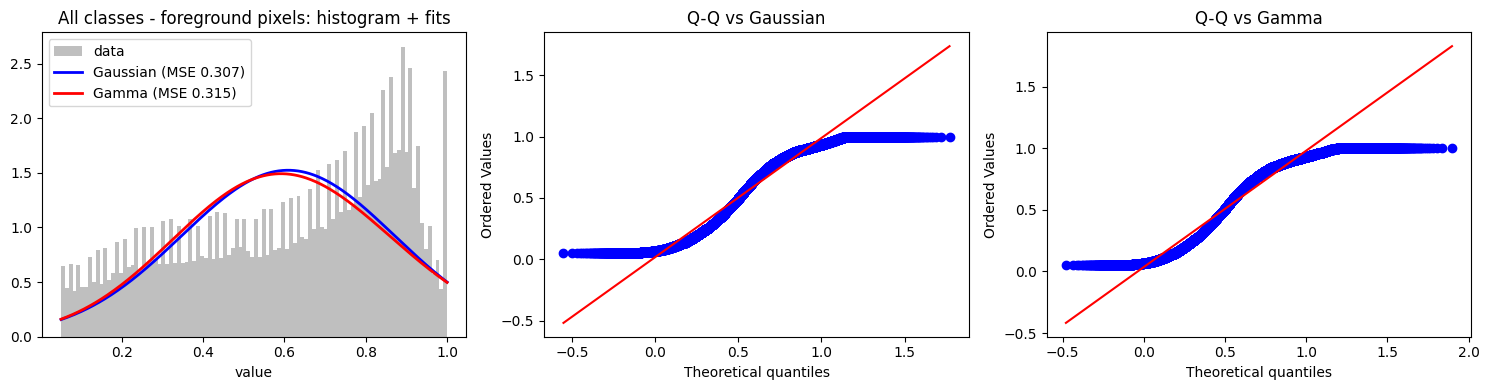

In [5]:
res_all = fit_and_compare(foreground_pixels(all_imgs), "All classes - foreground pixels")

## 5. (2) per-class foreground pixel intensities


===== T-shirt - foreground pixels   (n=150,000) =====
  Gaussian fit : mu=0.5875, sigma=0.2591
  Gamma fit    : a(shape)=250.2155, loc=-3.5700, scale=0.0166
  metric                Gaussian         Gamma   winner
  Histogram MSE           0.2614        0.2704   Gaussian
  AIC                  2.057e+04      2.29e+04   Gaussian
  BIC                  2.059e+04     2.293e+04   Gaussian
  KS statistic           0.08975       0.09408   Gaussian
  --> overall verdict: Gaussian  (0 Gamma / 4 Gaussian metric wins)


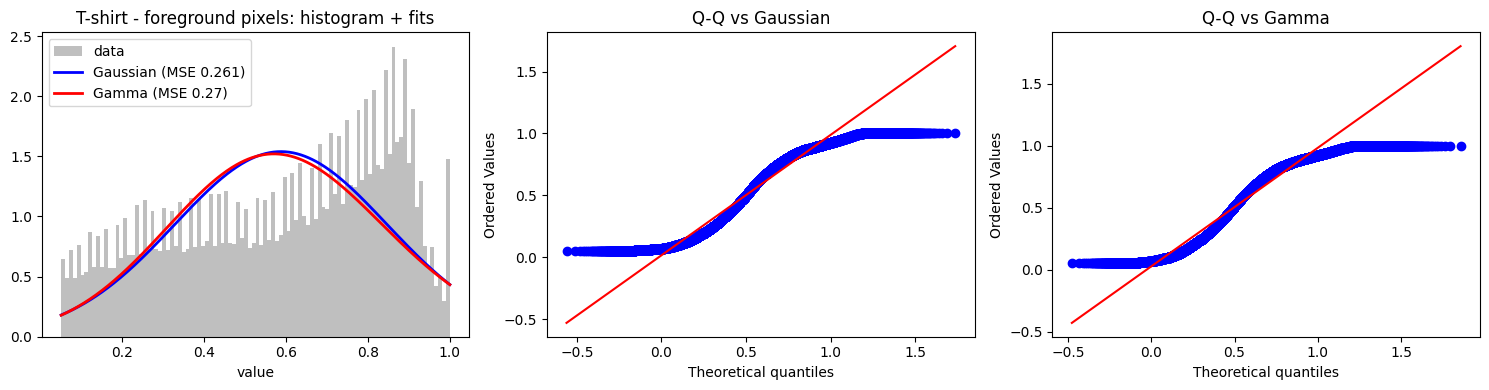


===== Pullover - foreground pixels   (n=150,000) =====
  Gaussian fit : mu=0.6045, sigma=0.2649
  Gamma fit    : a(shape)=235.4230, loc=-3.5218, scale=0.0175
  metric                Gaussian         Gamma   winner
  Histogram MSE           0.3236        0.3346   Gaussian
  AIC                  2.722e+04     2.962e+04   Gaussian
  BIC                  2.724e+04     2.965e+04   Gaussian
  KS statistic           0.09661        0.1033   Gaussian
  --> overall verdict: Gaussian  (0 Gamma / 4 Gaussian metric wins)


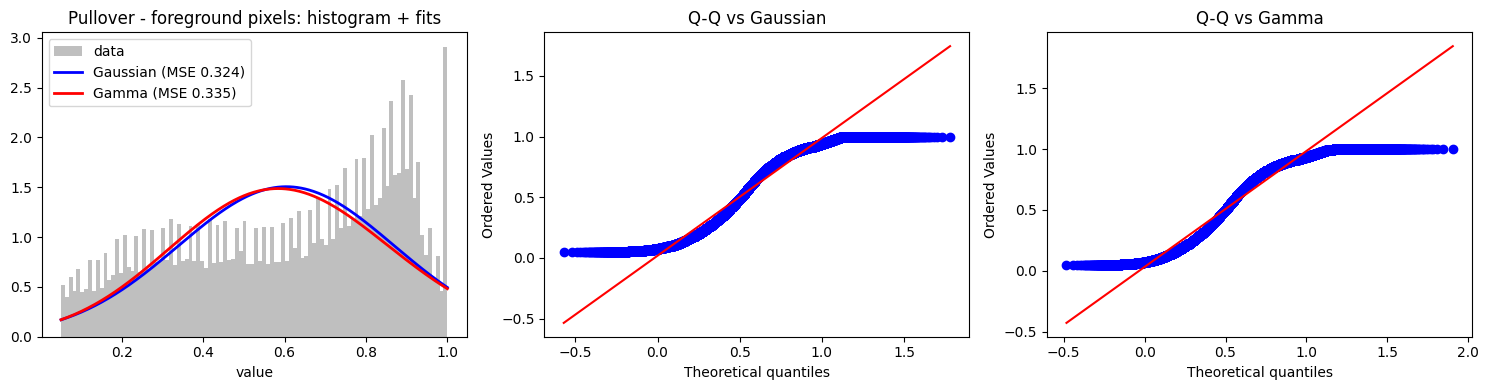


===== Dress - foreground pixels   (n=150,000) =====
  Gaussian fit : mu=0.6414, sigma=0.2582
  Gamma fit    : a(shape)=263.8783, loc=-3.6154, scale=0.0161
  metric                Gaussian         Gamma   winner
  Histogram MSE           0.3749        0.3951   Gaussian
  AIC                  1.951e+04     2.334e+04   Gaussian
  BIC                  1.953e+04     2.337e+04   Gaussian
  KS statistic            0.1056        0.1125   Gaussian
  --> overall verdict: Gaussian  (0 Gamma / 4 Gaussian metric wins)


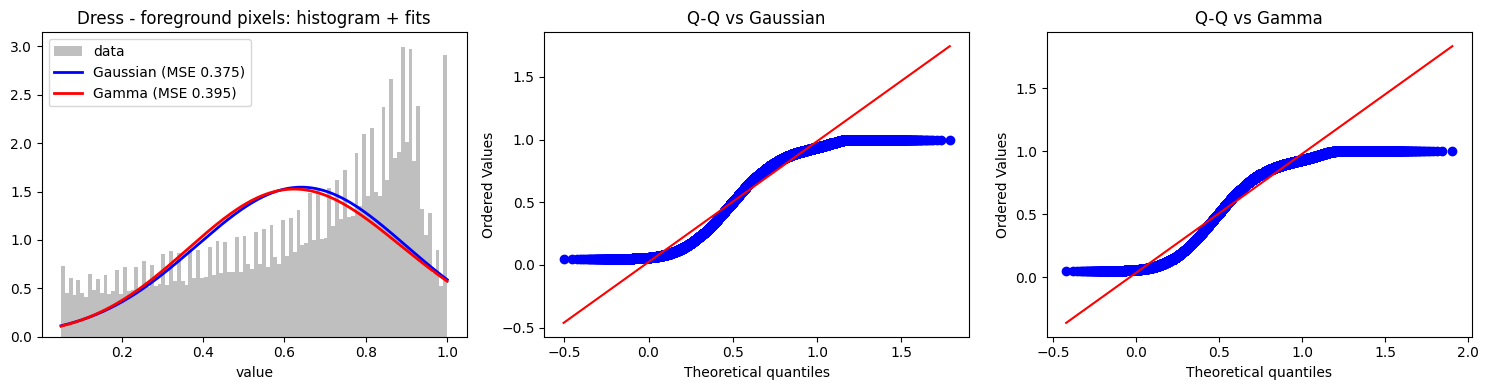

In [6]:
res_by_class = {}
for c in range(len(SEL)):
    res_by_class[c] = fit_and_compare(foreground_pixels(pix_by_class[c]),
                                      f"{NAMES[c]} - foreground pixels")

## 6. (3) per-image mean intensity (one value per image)


===== Per-image mean intensity   (n=4,500) =====
  Gaussian fit : mu=0.3192, sigma=0.1188
  Gamma fit    : a(shape)=52.8211, loc=-0.5444, scale=0.0163
  metric                Gaussian         Gamma   winner
  Histogram MSE           0.1252        0.1159   Gamma
  AIC                      -6400         -6434   Gamma
  BIC                      -6388         -6415   Gamma
  KS statistic            0.0326       0.03463   Gaussian
  --> overall verdict: Gamma  (3 Gamma / 1 Gaussian metric wins)


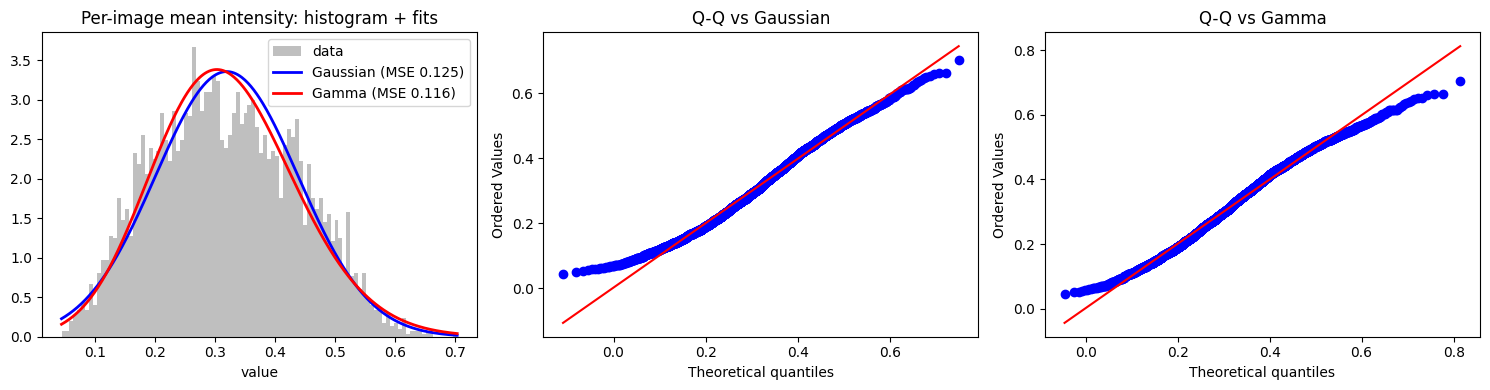

In [7]:
mean_intensity = all_imgs.reshape(all_imgs.shape[0], -1).mean(axis=1)
res_mean = fit_and_compare(mean_intensity, "Per-image mean intensity")

## 7. summary table

In [8]:
rows = [("All classes (fg pixels)", res_all),
        *[(f"{NAMES[c]} (fg pixels)", res_by_class[c]) for c in range(len(SEL))],
        ("Per-image mean intensity", res_mean)]
print("="*72)
print("SUMMARY  -  which distribution fits better (lower metric = better)")
print("="*72)
print(f"{'quantity':<28}{'Gauss MSE':>11}{'Gamma MSE':>11}{'Gauss KS':>10}{'Gamma KS':>10}   verdict")
for name, r in rows:
    print(f"{name:<28}{r['mse_norm']:>11.3g}{r['mse_gamma']:>11.3g}"
          f"{r['ks_norm']:>10.3g}{r['ks_gamma']:>10.3g}   {r['verdict']}")

SUMMARY  -  which distribution fits better (lower metric = better)
quantity                      Gauss MSE  Gamma MSE  Gauss KS  Gamma KS   verdict
All classes (fg pixels)           0.307      0.315    0.0963    0.0997   Gaussian
T-shirt (fg pixels)               0.261       0.27    0.0897    0.0941   Gaussian
Pullover (fg pixels)              0.324      0.335    0.0966     0.103   Gaussian
Dress (fg pixels)                 0.375      0.395     0.106     0.112   Gaussian
Per-image mean intensity          0.125      0.116    0.0326    0.0346   Gamma
